In [1]:
import os
import sys
sys.path.append(os.path.abspath('') + '/..')

In [2]:
from dataset_evaluation_utils import * 


import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')

# import plotly.offline as py
# pd.options.plotting.backend = "plotly"
# py.init_notebook_mode() # graphs charts inline (IPython).

a4_dims = (11.7, 8.27)

# paths

In [3]:
dataset_folderpath = '../datasets/lastfm1b/'

dataset_name = 'LastFM1b'

dump_foldername ='lastfm1b_dump/'
_, base_outputpath, _, _, _ = get_folderpaths(dump_foldername)


period=['2011-07', '2014-01']
sample = 'sample_'+str(period[0])+'_until_'+str(period[1])

sample_version_dump_foldername=dump_foldername+sample+'/'
filename = 'tracks_inter_merged_coldstart_11M'


# rule: what/which_data_set/sample_version/what/
images_path, output_path, heatmaps_path, diversity_graphpath, diversity_filepath = get_folderpaths(sample_version_dump_foldername)

In [5]:
interactions_df = pd.read_csv(output_path+filename+'_interactions_df.csv', index_col=0)
interactions_df['date'] = interactions_df['date'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d'))
interactions_df.head()

,user_id,item_id,timestamp,date
0,31435741,4,1385212958,2013-11-01
1,31435741,17,1381867823,2013-10-01
2,31435741,19,1381867431,2013-10-01
3,31435741,53,1370977938,2013-06-01
4,31435741,86,1369853851,2013-05-01


In [6]:
interactions_df.columns = ['user_id','item_id','timestamp','date']

In [7]:
interactions_df.shape

(7608520, 4)

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Load the dataset
# Replace 'dataset.csv' with your actual dataset file
# Ensure the dataset has columns: ['user_id', 'item_id', 'timestamp']
df = interactions_df.drop(columns=['date'])
df.head()

,user_id,item_id,timestamp
0,31435741,4,1385212958
1,31435741,17,1381867823
2,31435741,19,1381867431
3,31435741,53,1370977938
4,31435741,86,1369853851


In [9]:
# Step 1: Independence Check
# Correlation between consecutive interactions (temporal patterns)
df['time_diff'] = df['timestamp'].diff().fillna(0)
correlation = df['time_diff'].corr(df['item_id'].rank())  # Rank-based correlation
print(f"Time difference correlation with item ranks: {correlation}")

# Repeated interactions
repeated_interactions = df.duplicated(subset=['user_id', 'item_id']).sum()
print(f"Number of repeated interactions: {repeated_interactions}")

Time difference correlation with item ranks: -0.000843145212637221
Number of repeated interactions: 0


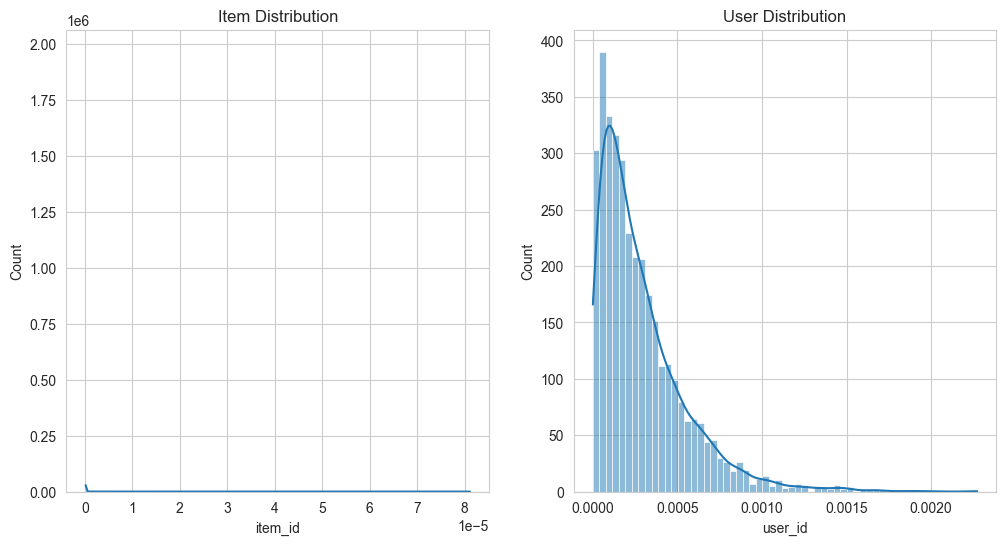

In [ ]:
# Step 2: Identical Distribution Check
# Distribution of items across users
item_distribution = df['item_id'].value_counts(normalize=True)
user_distribution = df['user_id'].value_counts(normalize=True)


# Visualization of distributions
plt.figure(figsize=(12, 6))

# Item distribution
plt.subplot(1, 2, 1)
sns.histplot(item_distribution, kde=True)
plt.title("Item Distribution")

# User distribution
plt.subplot(1, 2, 2)
sns.histplot(user_distribution, kde=True)
plt.title("User Distribution")

plt.show()


In [11]:
print(df['user_id'].describe())
print(df['item_id'].describe())

count    7.608520e+06
mean     2.014669e+07
std      1.487008e+07
min      1.000557e+06
25%      7.004146e+06
50%      1.571680e+07
75%      3.270235e+07
max      5.005488e+07
Name: user_id, dtype: float64
count    7.608520e+06
mean     1.015947e+06
std      1.261718e+06
min      1.000000e+00
25%      1.571990e+05
50%      5.623030e+05
75%      1.586785e+06
max      3.228386e+07
Name: item_id, dtype: float64


In [12]:
print("Unique user IDs:", df['user_id'].nunique())
print("Unique item IDs:", df['item_id'].nunique())
print("Max user ID:", df['user_id'].max())
print("Max item ID:", df['item_id'].max())


Unique user IDs: 3499
Unique item IDs: 2852453
Max user ID: 50054880
Max item ID: 32283856


In [13]:
# df.reset_index(drop=True, inplace=True)

# print("Unique user IDs:", df['user_id'].nunique())
# print("Unique item IDs:", df['item_id'].nunique())
# print("Max user ID:", df['user_id'].max())
# print("Max item ID:", df['item_id'].max())


In [14]:
df.head()

,user_id,item_id,timestamp,time_diff
0,31435741,4,1385212958,0.0
1,31435741,17,1381867823,-3345135.0
2,31435741,19,1381867431,-392.0
3,31435741,53,1370977938,-10889493.0
4,31435741,86,1369853851,-1124087.0


# test the code is equivalent

In [10]:
pd.crosstab(df.loc[:10,'user_id'], df.loc[:10,'item_id'])

item_id,4,17,19,53,86,127,131,182,204,219,231
user_id,,,,,,,,,,,
31435741,1,1,1,1,1,1,1,1,1,1,1


In [11]:
ij, tups = pd.factorize(list(zip(*map(df.loc[:10,['user_id', 'item_id']].get, df.loc[:10,['user_id', 'item_id']]))))
result = dict(zip(tups, np.bincount(ij)))
result

{(31435741, 4): 1,
 (31435741, 17): 1,
 (31435741, 19): 1,
 (31435741, 53): 1,
 (31435741, 86): 1,
 (31435741, 127): 1,
 (31435741, 131): 1,
 (31435741, 182): 1,
 (31435741, 204): 1,
 (31435741, 219): 1,
 (31435741, 231): 1}

In [12]:
pd.Series(result).unstack(fill_value=0)

,4,17,19,53,86,127,131,182,204,219,231
31435741,1,1,1,1,1,1,1,1,1,1,1


In [13]:
np.array(list(result.items()))

C:\Users\mjlav\AppData\Local\Temp\ipykernel_18948\4249493440.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  np.array(list(result.items()))


array([[(31435741, 4), 1],
       [(31435741, 17), 1],
       [(31435741, 19), 1],
       [(31435741, 53), 1],
       [(31435741, 86), 1],
       [(31435741, 127), 1],
       [(31435741, 131), 1],
       [(31435741, 182), 1],
       [(31435741, 204), 1],
       [(31435741, 219), 1],
       [(31435741, 231), 1]], dtype=object)

In [17]:
np.array([(key[0], key[1], value) for key, value in result.items()])

array([[31435741,        4,        1],
       [31435741,       17,        1],
       [31435741,       19,        1],
       [31435741,       53,        1],
       [31435741,       86,        1],
       [31435741,      127,        1],
       [31435741,      131,        1],
       [31435741,      182,        1],
       [31435741,      204,        1],
       [31435741,      219,        1],
       [31435741,      231,        1]], dtype=int64)

In [18]:
np.array(list(result.values()))

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

In [21]:
rows = sorted(set(key[0] for key in result.keys()))  # ['A', 'B', 'C']
cols = sorted(set(key[1] for key in result.keys()))  # ['1', '2', '3', '4']

# Create an empty array
r = np.zeros((len(rows), len(cols)))

# Fill the array with data
for (row_label, col_label), value in result.items():
    row_idx = rows.index(row_label)
    col_idx = cols.index(col_label)
    r[row_idx, col_idx] = value

print(r)

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


it does!!!

In [23]:
ij, tups = pd.factorize(list(zip(*map(df.loc[:,['user_id', 'item_id']].get, df.loc[:,['user_id', 'item_id']]))))
result = dict(zip(tups, np.bincount(ij)))
# result

In [24]:
rows = sorted(set(key[0] for key in result.keys()))  # ['A', 'B', 'C']
cols = sorted(set(key[1] for key in result.keys()))  # ['1', '2', '3', '4']

# Create an empty array
obs = np.zeros((len(rows), len(cols)))

# Fill the array with data
for (row_label, col_label), value in result.items():
    row_idx = rows.index(row_label)
    col_idx = cols.index(col_label)
    obs[row_idx, col_idx] = value

MemoryError: Unable to allocate 74.4 GiB for an array with shape (3499, 2852453) and data type float64

In [31]:
# pd.Series(result).unstack(fill_value=0) # pandas is the problem

In [ ]:
# Chi-square test to check uniformity
p_item = -1
_, p_item, _, _ = chi2_contingency(obs)
print(f"Chi-square test p-value for item distribution: {p_item:.4f} (low value = non-uniform)")


In [ ]:
# Step 3: IID Conditions Summary
print("\nIID Conditions Summary:")
if abs(correlation) < 0.1:
    print("1. Independence: PASSES (No strong temporal patterns)")
else:
    print("1. Independence: FAILS (Temporal patterns exist)")

if p_item > 0.05:
    print("2. Identical Distribution: PASSES (Uniform distribution of items/users)")
else:
    print("2. Identical Distribution: FAILS (Non-uniform distribution detected)")

if repeated_interactions == 0:
    print("3. Independence: PASSES (No repeated user-item interactions)")
else:
    print(f"3. Independence: FAILS ({repeated_interactions} repeated interactions detected)")

#########################################################################################################
# Original Code from chatGPT
* prompt "write the code to verify if the user-items interactions dataset fits the i.i.d. conditions
* on 09 Dec 2024
* OpenAI's GPT-4 model


recommended

Python 3.7 or later

pandas >= 1.0.0

numpy >= 1.18.0

seaborn >= 0.11.0

matplotlib >= 3.1.0

scipy >= 1.4.0

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Load the dataset
# Replace 'dataset.csv' with your actual dataset file
# Ensure the dataset has columns: ['user_id', 'item_id', 'timestamp']
df = pd.read_csv('dataset.csv')

# Step 1: Independence Check
# Correlation between consecutive interactions (temporal patterns)
df['time_diff'] = df['timestamp'].diff().fillna(0)
correlation = df['time_diff'].corr(df['item_id'].rank())  # Rank-based correlation
print(f"Time difference correlation with item ranks: {correlation}")

# Repeated interactions
repeated_interactions = df.duplicated(subset=['user_id', 'item_id']).sum()
print(f"Number of repeated interactions: {repeated_interactions}")

# Step 2: Identical Distribution Check
# Distribution of items across users
item_distribution = df['item_id'].value_counts(normalize=True)
user_distribution = df['user_id'].value_counts(normalize=True)

# Chi-square test to check uniformity
_, p_item, _, _ = chi2_contingency(pd.crosstab(df['user_id'], df['item_id']))
print(f"Chi-square test p-value for item distribution: {p_item:.4f} (low value = non-uniform)")

# Visualization of distributions
plt.figure(figsize=(12, 6))

# Item distribution
plt.subplot(1, 2, 1)
sns.histplot(item_distribution, kde=True)
plt.title("Item Distribution")

# User distribution
plt.subplot(1, 2, 2)
sns.histplot(user_distribution, kde=True)
plt.title("User Distribution")

plt.show()

# Step 3: IID Conditions Summary
print("\nIID Conditions Summary:")
if abs(correlation) < 0.1:
    print("1. Independence: PASSES (No strong temporal patterns)")
else:
    print("1. Independence: FAILS (Temporal patterns exist)")

if p_item > 0.05:
    print("2. Identical Distribution: PASSES (Uniform distribution of items/users)")
else:
    print("2. Identical Distribution: FAILS (Non-uniform distribution detected)")

if repeated_interactions == 0:
    print("3. Independence: PASSES (No repeated user-item interactions)")
else:
    print(f"3. Independence: FAILS ({repeated_interactions} repeated interactions detected)")
